# BrainCell vs NEURON: `ExpSyn` and `Exp2Syn`

This notebook compares the new BrainCell `ExpSyn` / `Exp2Syn` runtime templates against NEURON's built-in `ExpSyn` / `Exp2Syn` under the same `NetStim` timing configuration.

Important: the synaptic current shown here follows the NEURON sign convention. For excitatory synapses, `i = g * (v - e)` is often **negative**, so the meaningful peak magnitude is `abs(i).max()` rather than `max(i)`.

Note: the apparent ExpSyn current-peak mismatch is a sampling-phase issue, not a voltage-update difference. NEURON's point-process current recording can expose a step-start cached/event-boundary current sample, while the BrainCell traces shown here are sampled at the end of each step. Because ExpSyn jumps conductance immediately on an event, that boundary current can appear as an extra peak in NEURON. The membrane voltage update remains comparable.


In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import brainunit as u

os.environ.setdefault("JAX_PLATFORMS", "cpu")

def find_repo_root():
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "braincell").exists() and (candidate / "examples").exists():
            return candidate
    raise RuntimeError("Run this notebook from the repository root or a subdirectory inside it.")

repo_root = find_repo_root()
engine_dir = repo_root / "examples" / "neuron_compare" / "synapse" / "engine"
for path in (repo_root, engine_dir):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from braincell_runner import run_braincell_synapse_case
from neuron_runner import run_neuron_synapse_case
import brainstate
brainstate.environ.set(precision=64)



In [2]:
stim = {
    "netstim_start_ms": 10.0,
    "netstim_number": 1,
    "netstim_interval_ms": 10.0,
    "dt_ms": 0.05,
    "duration_ms": 40.0,
}

exp_syn_params = {
    "tau": 2.0 * u.ms,
    "e": 0.0 * u.mV,
    "weight": 1.0 * u.uS,
}

exp2_syn_params = {
    "tau1": 0.5 * u.ms,
    "tau2": 5.0 * u.ms,
    "e": 0.0 * u.mV,
    "weight": 1.0 * u.uS,
}


--No graphics will be displayed.


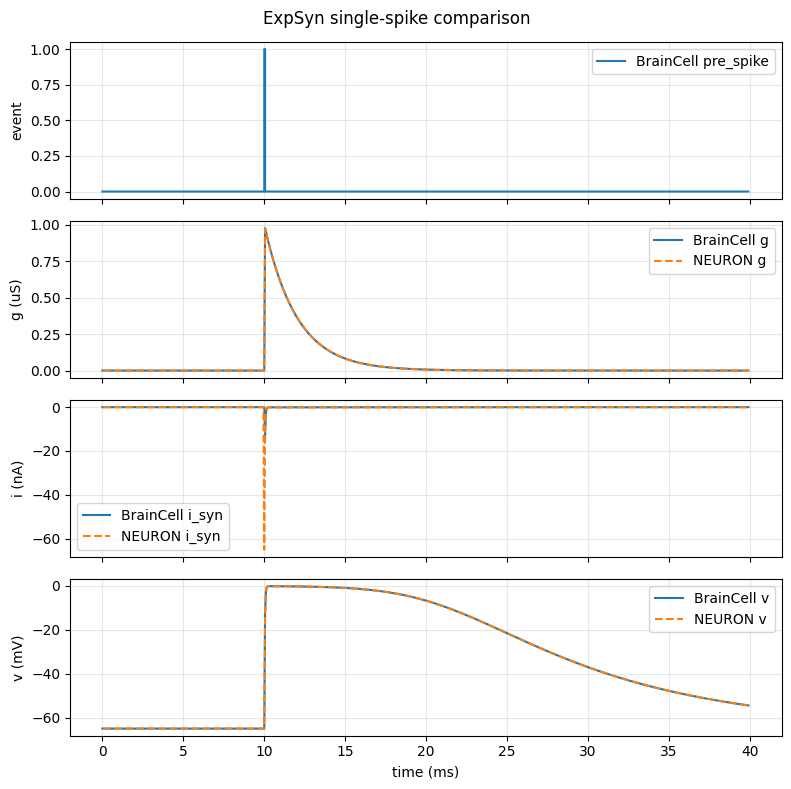

BrainCell current min/max (nA): -12.783654925261317 -0.0
NEURON current min/max (nA): -65.0 -0.0
BrainCell peak |current| (nA): 12.783654925261317
NEURON peak |current| (nA): 65.0


In [3]:
bc_exp = run_braincell_synapse_case(synapse_type="ExpSyn", synapse_name="exp_syn", synapse_params=exp_syn_params, **stim)
nrn_exp = run_neuron_synapse_case(synapse_type="ExpSyn", synapse_params=exp_syn_params, **stim)

fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True)
axes[0].step(bc_exp["time_ms"], bc_exp["pre_spike"], where="post", label="BrainCell pre_spike")
axes[0].set_ylabel("event")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(bc_exp["time_ms"], bc_exp["g_uS"], label="BrainCell g")
if "g_uS" in nrn_exp:
    axes[1].plot(nrn_exp["time_ms"], nrn_exp["g_uS"], label="NEURON g", linestyle="--")
axes[1].set_ylabel("g (uS)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(bc_exp["time_ms"], bc_exp["current_nA"], label="BrainCell i_syn")
axes[2].plot(nrn_exp["time_ms"], nrn_exp["current_nA"], label="NEURON i_syn", linestyle="--")
axes[2].set_ylabel("i (nA)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

axes[3].plot(bc_exp["time_ms"], bc_exp["voltage_mV"], label="BrainCell v")
axes[3].plot(nrn_exp["time_ms"], nrn_exp["voltage_mV"], label="NEURON v", linestyle="--")
axes[3].set_ylabel("v (mV)")
axes[3].set_xlabel("time (ms)")
axes[3].legend()
axes[3].grid(True, alpha=0.3)
plt.suptitle("ExpSyn single-spike comparison")
plt.tight_layout()
plt.show()

print("BrainCell current min/max (nA):", bc_exp["current_nA"].min(), bc_exp["current_nA"].max())
print("NEURON current min/max (nA):", nrn_exp["current_nA"].min(), nrn_exp["current_nA"].max())
print("BrainCell peak |current| (nA):", abs(bc_exp["current_nA"]).max())
print("NEURON peak |current| (nA):", abs(nrn_exp["current_nA"]).max())


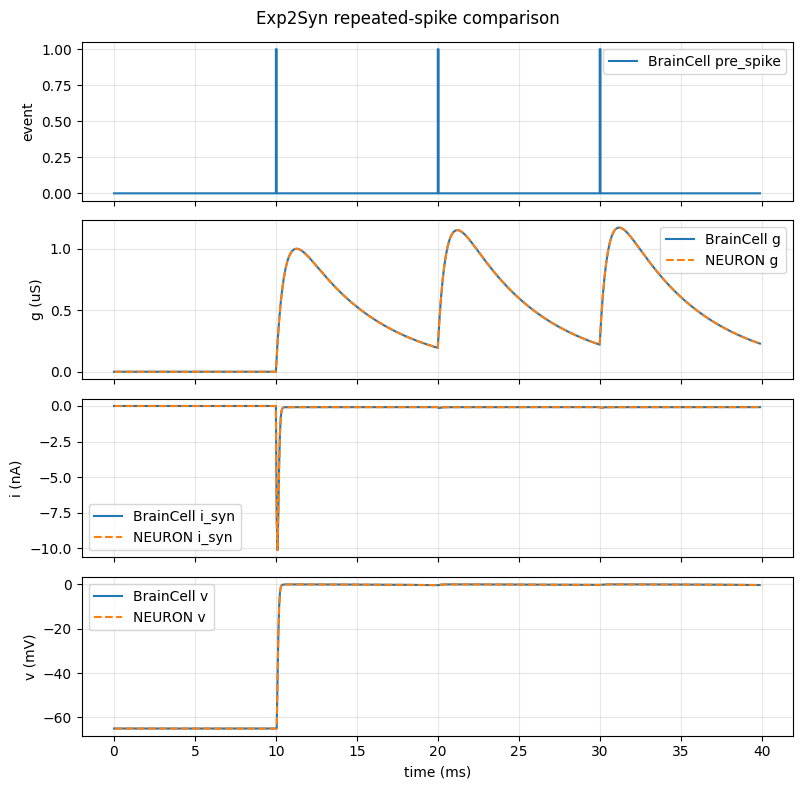

BrainCell current min/max (nA): -10.148342214712251 -0.0
NEURON current min/max (nA): -10.148342214715 -0.0
BrainCell peak |current| (nA): 10.148342214712251
NEURON peak |current| (nA): 10.148342214715


In [4]:
stim_multi = dict(stim)
stim_multi["netstim_number"] = 4

bc_exp2 = run_braincell_synapse_case(synapse_type="Exp2Syn", synapse_name="exp2_syn", synapse_params=exp2_syn_params, **stim_multi)
nrn_exp2 = run_neuron_synapse_case(synapse_type="Exp2Syn", synapse_params=exp2_syn_params, **stim_multi)

fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True)
axes[0].step(bc_exp2["time_ms"], bc_exp2["pre_spike"], where="post", label="BrainCell pre_spike")
axes[0].set_ylabel("event")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(bc_exp2["time_ms"], bc_exp2["g_uS"], label="BrainCell g")
if "g_uS" in nrn_exp2:
    axes[1].plot(nrn_exp2["time_ms"], nrn_exp2["g_uS"], label="NEURON g", linestyle="--")
axes[1].set_ylabel("g (uS)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(bc_exp2["time_ms"], bc_exp2["current_nA"], label="BrainCell i_syn")
axes[2].plot(nrn_exp2["time_ms"], nrn_exp2["current_nA"], label="NEURON i_syn", linestyle="--")
axes[2].set_ylabel("i (nA)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

axes[3].plot(bc_exp2["time_ms"], bc_exp2["voltage_mV"], label="BrainCell v")
axes[3].plot(nrn_exp2["time_ms"], nrn_exp2["voltage_mV"], label="NEURON v", linestyle="--")
axes[3].set_ylabel("v (mV)")
axes[3].set_xlabel("time (ms)")
axes[3].legend()
axes[3].grid(True, alpha=0.3)
plt.suptitle("Exp2Syn repeated-spike comparison")
plt.tight_layout()
plt.show()

print("BrainCell current min/max (nA):", bc_exp2["current_nA"].min(), bc_exp2["current_nA"].max())
print("NEURON current min/max (nA):", nrn_exp2["current_nA"].min(), nrn_exp2["current_nA"].max())
print("BrainCell peak |current| (nA):", abs(bc_exp2["current_nA"]).max())
print("NEURON peak |current| (nA):", abs(nrn_exp2["current_nA"]).max())
